# Laboratorio 5
## Sebastian Huertas 22295

In [1]:
!pip install scapy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 41.5 MB/s eta 0:00:00


In [2]:
from scapy.all import *
import pandas as pd
import numpy as np
import binascii
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
sns.set(color_codes=True)
%matplotlib inline

In [3]:
from google.colab import files
uploaded = files.upload()

Saving analisis_paquetes.pcap to analisis_paquetes.pcap


# Parte 1

In [4]:
num_of_packets_to_sniff = 10
pcap = rdpcap("analisis_paquetes.pcap")[:10]

print(type(pcap))
print(len(pcap))
print(pcap)

<class 'scapy.plist.PacketList'>
10
<mod analisis_paquetes.pcap: TCP:0 UDP:10 ICMP:0 Other:0>


In [5]:
for packet in pcap:
    if IP in packet:
        src = packet[IP].src
        dst = packet[IP].dst
        sport = packet.sport if hasattr(packet, 'sport') else None
        dport = packet.dport if hasattr(packet, 'dport') else None
        print(f"Src: {src} | Dst: {dst} | Src Port: {sport} | Dst Port: {dport}")

Src: 10.1.10.53 | Dst: 84.54.22.33 | Src Port: 53 | Dst Port: 53
Src: 84.54.22.33 | Dst: 10.1.10.53 | Src Port: 53 | Dst Port: 53
Src: 10.1.10.53 | Dst: 84.54.22.33 | Src Port: 53 | Dst Port: 53
Src: 84.54.22.33 | Dst: 10.1.10.53 | Src Port: 53 | Dst Port: 53
Src: 10.1.10.53 | Dst: 84.54.22.33 | Src Port: 53 | Dst Port: 53
Src: 84.54.22.33 | Dst: 10.1.10.53 | Src Port: 53 | Dst Port: 53
Src: 10.1.10.53 | Dst: 84.54.22.33 | Src Port: 53 | Dst Port: 53
Src: 84.54.22.33 | Dst: 10.1.10.53 | Src Port: 53 | Dst Port: 53
Src: 10.1.10.53 | Dst: 84.54.22.33 | Src Port: 53 | Dst Port: 53
Src: 84.54.22.33 | Dst: 10.1.10.53 | Src Port: 53 | Dst Port: 53


In [6]:
pcap = rdpcap("analisis_paquetes.pcap")
print(len(pcap))

62


In [7]:
ip_fields = [field.name for field in IP().fields_desc]
tcp_fields = [field.name for field in TCP().fields_desc]
udp_fields = [field.name for field in UDP().fields_desc]

dataframe_fields = ip_fields + ['time'] + udp_fields + ['payload','payload_raw','payload_hex']

df = pd.DataFrame(columns=dataframe_fields)

for packet in pcap[IP]:
    field_values = []
    for field in ip_fields:
        if field == 'options':
            field_values.append(len(packet[IP].fields[field]))
        else:
            field_values.append(packet[IP].fields[field])

    field_values.append(packet.time)

    layer_type = type(packet[IP].payload)
    for field in udp_fields:
        try:
            if field == 'options':
                field_values.append(len(packet[layer_type].fields[field]))
            else:
                field_values.append(packet[layer_type].fields[field])
        except:
            field_values.append(None)

    field_values.append(len(packet[layer_type].payload))
    field_values.append(packet[layer_type].payload.original)
    field_values.append(binascii.hexlify(packet[layer_type].payload.original))

    df_append = pd.DataFrame([field_values], columns=dataframe_fields)
    df = pd.concat([df, df_append], axis=0)

df = df.reset_index()
df = df.drop(columns="index")
df.head()

,version,ihl,tos,len,id,flags,frag,ttl,proto,chksum,...,dst,options,time,sport,dport,len,chksum,payload,payload_raw,payload_hex
0,4,5,0,961,1,,0,64,17,21222,...,84.54.22.33,0,1532199330.917674,53,53,941,62990,933,b'\x00\x0c\x01\x00\x00\x01\x00\x00\x00\x00\x00...,b'000c0100000100000000000006676f6f676c6503636f...
1,4,5,32,84,58919,,0,122,17,13836,...,10.1.10.53,0,1532199330.950107,53,53,64,65061,56,b'\x00\x0c\x81\x80\x00\x01\x00\x01\x00\x00\x00...,b'000c8180000100010000000006676f6f676c6503636f...
2,4,5,0,975,1,,0,64,17,21208,...,84.54.22.33,0,1532199331.937777,53,53,955,36378,947,b'\x00\x0c\x01\x00\x00\x01\x00\x00\x00\x00\x00...,b'000c0100000100000000000006676f6f676c6503636f...
3,4,5,32,84,59493,,0,122,17,13262,...,10.1.10.53,0,1532199331.956635,53,53,64,65063,56,b'\x00\x0c\x81\x80\x00\x01\x00\x01\x00\x00\x00...,b'000c8180000100010000000006676f6f676c6503636f...
4,4,5,0,1012,1,,0,64,17,21171,...,84.54.22.33,0,1532199332.960504,53,53,992,63846,984,b'\x00\x0c\x01\x00\x00\x01\x00\x00\x00\x00\x00...,b'000c0100000100000000000006676f6f676c6503636f...


## Punto 3

In [9]:
print("a. IP origen mas frecuente:")
print(df['src'].describe()['top'])

print("\nb. IP destino mas frecuente:")
print(df['dst'].describe()['top'])

frequent_src = df['src'].describe()['top']
print(f"\nc. IPs con las que se comunica {frequent_src}:")
print(df[df['src'] == frequent_src]['dst'].unique())

a. IP origen mas frecuente:
10.1.10.53

b. IP destino mas frecuente:
10.1.10.53

c. IPs con las que se comunica 10.1.10.53:
['84.54.22.33' '75.75.75.75']


In [10]:
frequent_src = df['src'].describe()['top']
frequent_dst = df['dst'].describe()['top']

print(f"d. Puertos destino a los que se comunica {frequent_src}:")
print(df[df['src'] == frequent_src]['dport'].unique())

print(f"\ne. Puertos origen desde los que se comunica {frequent_dst}:")
print(df[df['dst'] == frequent_dst]['sport'].unique())

d. Puertos destino a los que se comunica 10.1.10.53:
[53]

e. Puertos origen desde los que se comunica 10.1.10.53:
[53]


### f - Propósito de los puertos

El puerto 53 es el puerto estándar del protocolo DNS (Domain Name System).
Su propósito es resolver nombres de dominio a direcciones IP. Opera tanto en UDP como en TCP.
Toda la comunicación capturada en este pcap ocurre sobre el puerto 53, lo que indica
que el tráfico analizado corresponde exclusivamente a consultas y respuestas DNS.

## Punto 4

In [13]:
df['payload'] = pd.to_numeric(df['payload'], errors='coerce')

df['zscore_payload'] = stats.zscore(df['payload'].dropna())

print("Paquetes con |Z| > 2:")
print(df[df['zscore_payload'].abs() > 2][['src', 'dst', 'sport', 'dport', 'payload', 'zscore_payload']])

print("\n Paquetes con |Z| > 3:")
print(df[df['zscore_payload'].abs() > 3][['src', 'dst', 'sport', 'dport', 'payload', 'zscore_payload']])

Paquetes con |Z| > 2:
Empty DataFrame
Columns: [src, dst, sport, dport, payload, zscore_payload]
Index: []

 Paquetes con |Z| > 3:
Empty DataFrame
Columns: [src, dst, sport, dport, payload, zscore_payload]
Index: []


### a - Z-Score sobre payload

No se encontraron paquetes anómalos con |Z| > 2 ni |Z| > 3.
Esto se debe a que el Z-score se calcula usando la media y desviación estándar
del propio pcap, por lo que si todos los paquetes tienen tamaños relativamente
similares entre sí, ninguno se aleja lo suficiente de la media para ser marcado
como anomalía.

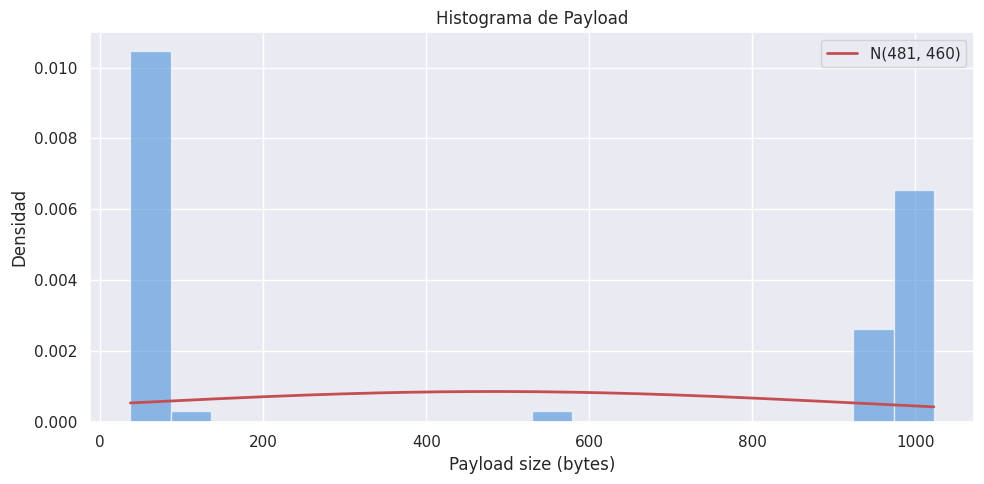

In [14]:
plt.figure(figsize=(10, 5))
plt.hist(df['payload'].dropna(), bins=20, color='#4A90D9', edgecolor='white', density=True, alpha=0.6)

mu, sigma = df['payload'].mean(), df['payload'].std()
x = np.linspace(df['payload'].min(), df['payload'].max(), 200)
plt.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', lw=2, label=f'N({mu:.0f}, {sigma:.0f})')

plt.title('Histograma de Payload')
plt.xlabel('Payload size (bytes)')
plt.ylabel('Densidad')
plt.legend()
plt.tight_layout()
plt.show()

### b - Histograma de Payload

La distribución no es normal. Se observa una distribución bimodal con dos grupos
bien separados: uno con payloads pequeños (alrededor de 50 bytes, consultas DNS normales)
y otro con payloads muy grandes (alrededor de 950-1000 bytes, tráfico sospechoso).

Esto explica por qué el Z-score no detectó anomalías: al calcular la media y desviación
estándar del propio pcap, ambos grupos "jalan" la media hacia el centro (481 bytes)
y generan una desviación estándar muy alta (460 bytes). Con esos parámetros,
ningún paquete queda realmente lejos de la media en términos de Z-score,
aunque visualmente los grupos están muy separados.

In [15]:
dns_mean = 50
dns_std = 15

df['zscore_domain'] = (df['payload'] - dns_mean) / dns_std

anomalies = df[df['zscore_domain'].abs() > 2]

print(f"Paquetes anomalos detectados: {len(anomalies)}")
print(anomalies[['src', 'dst', 'sport', 'dport', 'payload', 'zscore_domain']])

Paquetes anomalos detectados: 30
            src          dst sport  dport  payload  zscore_domain
0    10.1.10.53  84.54.22.33    53     53      933      58.866667
2    10.1.10.53  84.54.22.33    53     53      947      59.800000
4    10.1.10.53  84.54.22.33    53     53      984      62.266667
6    10.1.10.53  84.54.22.33    53     53      970      61.333333
8    10.1.10.53  84.54.22.33    53     53      975      61.666667
10   10.1.10.53  84.54.22.33    53     53     1017      64.466667
12   10.1.10.53  84.54.22.33    53     53      980      62.000000
14   10.1.10.53  84.54.22.33    53     53      951      60.066667
16   10.1.10.53  84.54.22.33    53     53      931      58.733333
18   10.1.10.53  84.54.22.33    53     53      964      60.933333
20   10.1.10.53  84.54.22.33    53     53     1023      64.866667
25  75.75.75.75   10.1.10.53    53  23903       89       2.600000
26   10.1.10.53  84.54.22.33    53     53      978      61.866667
28   10.1.10.53  84.54.22.33    53     53  

### c - Z-Score con conocimiento de dominio DNS

Se detectaron 30 paquetes anómalos usando media=50 bytes y desviación=15 bytes
como referencia del protocolo DNS.

La mayoría provienen de 10.1.10.53 hacia 84.54.22.33, con payloads entre
560 y 1023 bytes, valores extremadamente altos para una consulta DNS normal.
Sus Z-scores superan 34, llegando hasta ~65, lo que indica que están muy por
encima de lo esperado para tráfico DNS legítimo.

### d - Importancia del conocimiento de dominio

Cuando el Z-score se calcula con los parámetros del propio dataset, si este ya contiene
tráfico anómalo, la media y desviación se ven distorsionadas por los valores atípicos,
haciendo que ningún paquete parezca anómalo.

Conocer el protocolo analizado (en este caso DNS, con consultas típicas de 50 bytes)
permite usar valores de referencia reales como base del Z-score, lo que hace la detección
mucho más efectiva. Sin ese conocimiento, las técnicas estadísticas pueden fallar
completamente aunque el tráfico malicioso sea evidente visualmente.

## Punto 5

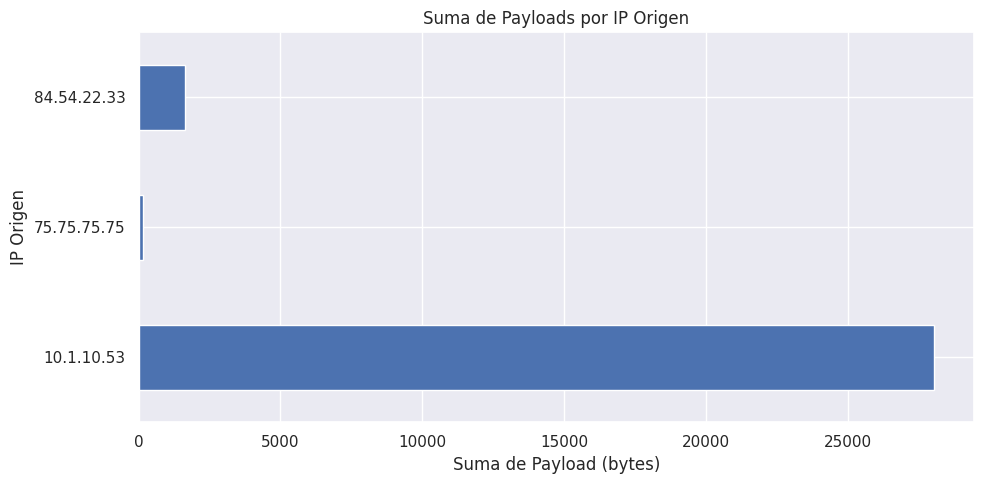

In [16]:
src_payload = df.groupby('src')['payload'].sum()

plt.figure(figsize=(10, 5))
src_payload.plot(kind='barh')
plt.title('Suma de Payloads por IP Origen')
plt.xlabel('Suma de Payload (bytes)')
plt.ylabel('IP Origen')
plt.tight_layout()
plt.show()

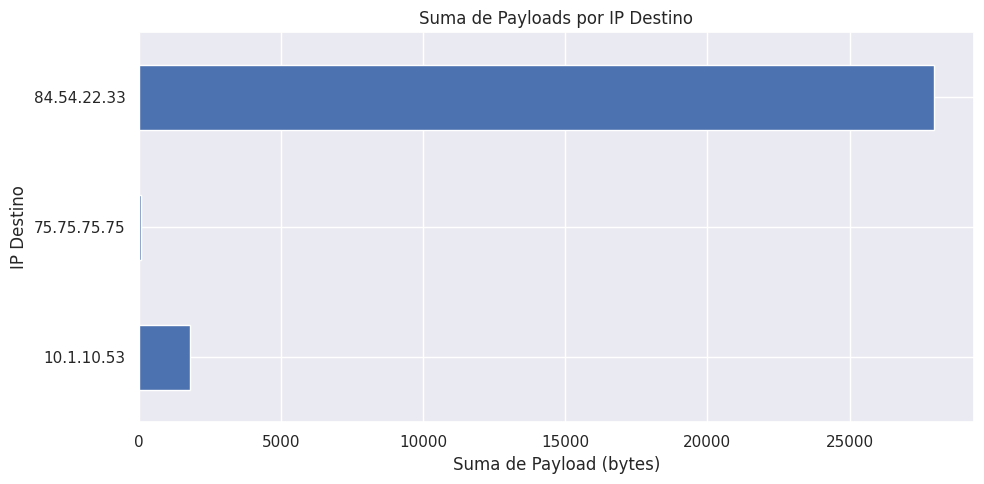

In [17]:
dst_payload = df.groupby('dst')['payload'].sum()

plt.figure(figsize=(10, 5))
dst_payload.plot(kind='barh')
plt.title('Suma de Payloads por IP Destino')
plt.xlabel('Suma de Payload (bytes)')
plt.ylabel('IP Destino')
plt.tight_layout()
plt.show()

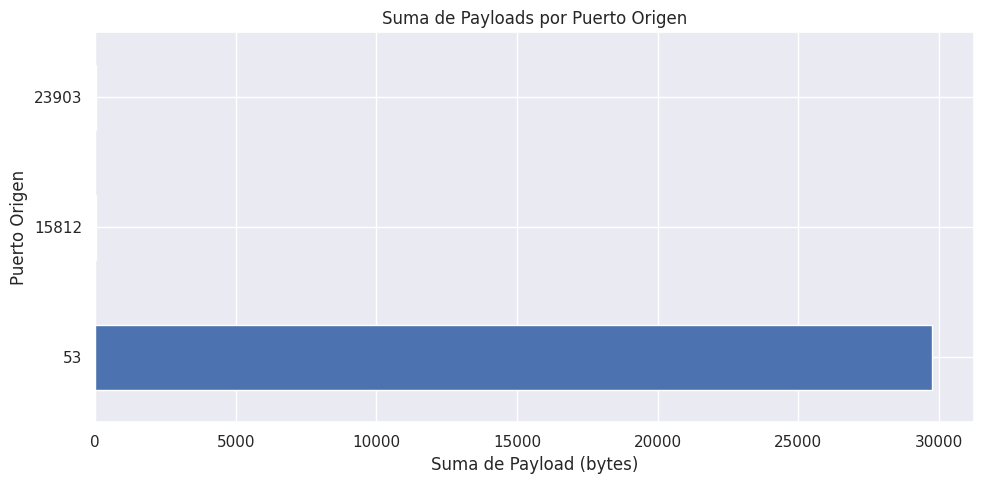

In [18]:
sport_payload = df.groupby('sport')['payload'].sum()

plt.figure(figsize=(10, 5))
sport_payload.plot(kind='barh')
plt.title('Suma de Payloads por Puerto Origen')
plt.xlabel('Suma de Payload (bytes)')
plt.ylabel('Puerto Origen')
plt.tight_layout()
plt.show()

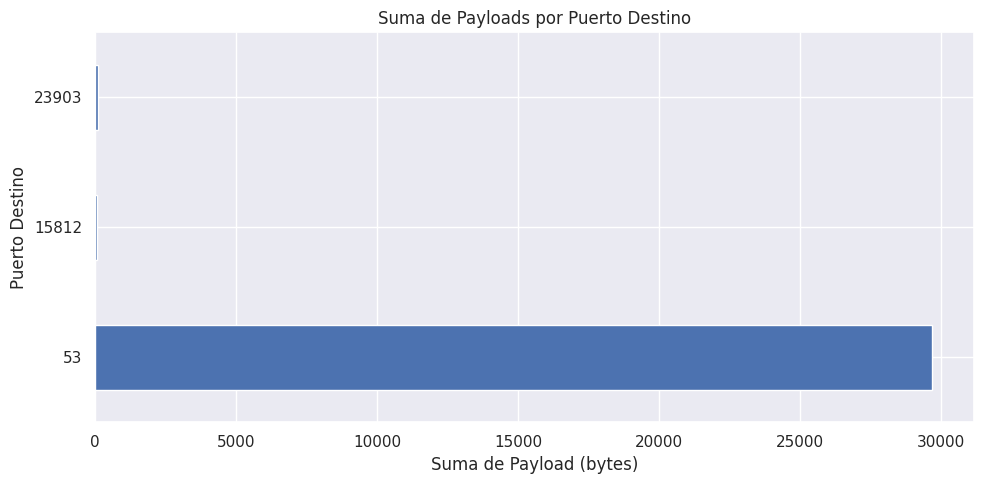

In [19]:
dport_payload = df.groupby('dport')['payload'].sum()

plt.figure(figsize=(10, 5))
dport_payload.plot(kind='barh')
plt.title('Suma de Payloads por Puerto Destino')
plt.xlabel('Suma de Payload (bytes)')
plt.ylabel('Puerto Destino')
plt.tight_layout()
plt.show()

## Punto 6

In [22]:
from sklearn.ensemble import IsolationForest

anomalies_4c = 30
total_packets = len(df)
contamination = anomalies_4c / total_packets

df.columns = ['ip_version', 'ihl', 'tos', 'ip_len', 'id', 'flags', 'frag', 'ttl', 'proto', 'ip_chksum', 'src', 'dst', 'options', 'time', 'sport', 'dport', 'udp_len', 'udp_chksum', 'payload', 'payload_raw', 'payload_hex', 'zscore_payload', 'zscore_domain']

df['ip_len'] = pd.to_numeric(df['ip_len'], errors='coerce')
df['payload'] = pd.to_numeric(df['payload'], errors='coerce')

features = df[['ip_len', 'payload']].dropna()

iso = IsolationForest(contamination=contamination, random_state=42)
df['anomaly'] = iso.fit_predict(features)

anomalies_if = df[df['anomaly'] == -1]
print(f"Paquetes marcados como anomalias: {len(anomalies_if)}")
print(anomalies_if[['src', 'dst', 'sport', 'dport', 'ip_len', 'payload']])

Paquetes marcados como anomalias: 30
            src          dst  sport  dport  ip_len  payload
0    10.1.10.53  84.54.22.33     53     53     961      933
2    10.1.10.53  84.54.22.33     53     53     975      947
4    10.1.10.53  84.54.22.33     53     53    1012      984
6    10.1.10.53  84.54.22.33     53     53     998      970
8    10.1.10.53  84.54.22.33     53     53    1003      975
10   10.1.10.53  84.54.22.33     53     53    1045     1017
12   10.1.10.53  84.54.22.33     53     53    1008      980
14   10.1.10.53  84.54.22.33     53     53     979      951
16   10.1.10.53  84.54.22.33     53     53     959      931
18   10.1.10.53  84.54.22.33     53     53     992      964
20   10.1.10.53  84.54.22.33     53     53    1051     1023
22   10.1.10.53  75.75.75.75  15812     53      65       37
23   10.1.10.53  75.75.75.75  23903     53      65       37
24  75.75.75.75   10.1.10.53     53  15812     105       77
25  75.75.75.75   10.1.10.53     53  23903     117       89
28 

### b - Comparacion Isolation Forest vs Z-Score

Las anomalías detectadas por Isolation Forest coinciden en gran medida con las del Z-score
con conocimiento de dominio. Ambas técnicas identifican los mismos paquetes provenientes
de 10.1.10.53 hacia 84.54.22.33 con payloads entre 560 y 1023 bytes como sospechosos.

Isolation Forest adicionalmente marca algunos paquetes de la conversación con
75.75.75.75 (índices 22, 23, 24, 25), lo que sugiere que ese tráfico también
tiene características atípicas respecto al resto del pcap, aunque con payloads menores.

Esto confirma que ambas técnicas apuntan a la misma conversación sospechosa,
dando mayor confianza en que el tráfico hacia 84.54.22.33 es anómalo.

## Punto 7

In [24]:
frequent_src = df['src'].describe()['top']
print(f"a. IP origen mas frecuente: {frequent_src}")

df_frequent = df[df['src'] == frequent_src]
print(f"Total de conexiones: {len(df_frequent)}")
df_frequent.head()

a. IP origen mas frecuente: 10.1.10.53
Total de conexiones: 31


,ip_version,ihl,tos,ip_len,id,flags,frag,ttl,proto,ip_chksum,...,sport,dport,udp_len,udp_chksum,payload,payload_raw,payload_hex,zscore_payload,zscore_domain,anomaly
0,4,5,0,961,1,,0,64,17,21222,...,53,53,941,62990,933,b'\x00\x0c\x01\x00\x00\x01\x00\x00\x00\x00\x00...,b'000c0100000100000000000006676f6f676c6503636f...,0.989307,58.866667,-1
2,4,5,0,975,1,,0,64,17,21208,...,53,53,955,36378,947,b'\x00\x0c\x01\x00\x00\x01\x00\x00\x00\x00\x00...,b'000c0100000100000000000006676f6f676c6503636f...,1.019972,59.800000,-1
4,4,5,0,1012,1,,0,64,17,21171,...,53,53,992,63846,984,b'\x00\x0c\x01\x00\x00\x01\x00\x00\x00\x00\x00...,b'000c0100000100000000000006676f6f676c6503636f...,1.101016,62.266667,-1
6,4,5,0,998,1,,0,64,17,21185,...,53,53,978,65315,970,b'\x00\x0c\x01\x00\x00\x01\x00\x00\x00\x00\x00...,b'000c0100000100000000000006676f6f676c6503636f...,1.070351,61.333333,-1
8,4,5,0,1003,1,,0,64,17,21180,...,53,53,983,38088,975,b'\x00\x0c\x01\x00\x00\x01\x00\x00\x00\x00\x00...,b'000c0100000100000000000006676f6f676c6503636f...,1.081303,61.666667,-1


In [25]:
df_grouped = df_frequent.groupby(['src', 'dst'])['payload'].sum().reset_index()
print('b.\n', df_grouped)

b.
           src          dst  payload
0  10.1.10.53  75.75.75.75       74
1  10.1.10.53  84.54.22.33    27979


In [26]:
top_dst = df_grouped.loc[df_grouped['payload'].idxmax()]
print(f"c. IP que mas bytes ha intercambiado con {frequent_src}:")
print(top_dst)

c. IP que mas bytes ha intercambiado con 10.1.10.53:
src         10.1.10.53
dst        84.54.22.33
payload          27979
Name: 1, dtype: object


In [27]:
suspicious_ip = '84.54.22.33'

df_conversation = df[
    ((df['src'] == frequent_src) & (df['dst'] == suspicious_ip)) |
    ((df['src'] == suspicious_ip) & (df['dst'] == frequent_src))
]

print(f"Total de paquetes en la conversacion: {len(df_conversation)}")
df_conversation[['src', 'dst', 'sport', 'dport', 'payload']].head()

Total de paquetes en la conversacion: 58


,src,dst,sport,dport,payload
0,10.1.10.53,84.54.22.33,53,53,933
1,84.54.22.33,10.1.10.53,53,53,56
2,10.1.10.53,84.54.22.33,53,53,947
3,84.54.22.33,10.1.10.53,53,53,56
4,10.1.10.53,84.54.22.33,53,53,984


In [28]:
payload_array = df_conversation['payload_raw'].values
print(f"Total de payloads en el array: {len(payload_array)}")

Total de payloads en el array: 58


In [29]:
print(payload_array[0])

b'\x00\x0c\x01\x00\x00\x01\x00\x00\x00\x00\x00\x00\x06google\x03com\x00\x00\x1c\x00\x01\xef\xbf\xbdPNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x01b\x00\x00\x00\xef\xbf\xbd\x08\x06\x00\x00\x00(\xef\xbf\xbdTR\x00\x00:\xef\xbf\xbdIDATx\xef\xbf\xbd\xef\xbf\xbd\t|T\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbd;K\x12\x08;\x08\xef\xbf\xbd\nE\xef\xbf\xbd\xef\xbf\xbd$\x19\xef\xbf\xbd\xef\xbf\xbdZi\xdf\xaa-\xef\xbf\xbd;N2\xef\xbf\xbd\xef\xbf\xbdV\xef\xbf\xbdV\xef\xbf\xbda\xef\xbf\xbdZ\x11!\xef\xbf\xbd\xef\xbf\xbd\x01\xdc\xbbik[\xef\xbf\xbd.ok\xef\xbf\xbde\xef\xbf\xbd\x01\\\xef\xbf\xbd\xef\xbf\xbd]\xef\xbf\xbd-\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbdd\xef\xbf\xbd\x08\xef\xbf\xbd\x08\xef\xbf\xbd\xef\xbf\xbdg\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbd<\xef\xbf\xbd\xef\xbf\xbdL\x12\xef\xbf\xbd$3wf\xef\xbf\xbd\xef\xbf\xbd\x02<_\r\xef\xbf\xbdY\xef\xbf\xbdr\xef\xbf\xbd\xef\xbf\xbdy\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbd\x1c\r\x18\xef\xbf\xbd8c\xef\xbf\xbdew\r\x1e\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbd\xef\xbf

### g - Analisis del payload e identificacion del ataque

En el payload se puede observar claramente la firma `PNG\r\n\x1a\n` seguida de
`IHDR` e `IDAT`, que son cabeceras del formato de imagen PNG.
Esto no tiene ningún sentido dentro de una consulta DNS, cuyo proposito es
unicamente resolver nombres de dominio a direcciones IP.

El ataque detectado es DNS Tunneling: una tecnica en la que un atacante
utiliza el protocolo DNS (puerto 53) para exfiltrar datos, en este caso
archivos de imagen PNG, ocultandolos dentro de consultas DNS aparentemente
legitimas hacia 84.54.22.33.

Esto es importante porque combinar tecnicas automaticas con inspeccion manual
del payload permite confirmar el tipo de ataque. Las tecnicas automaticas
(Z-score, Isolation Forest) solo indican que algo es anomalo por su tamano,
pero no pueden determinar el tipo de ataque sin inspeccionar el contenido.
La investigacion manual del payload es la que confirma que se trata de
exfiltracion de datos via DNS Tunneling.